In [2]:
import pandas as pd
df = pd.read_csv("/content/calories.csv")
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [3]:
#User_ID is not needed
df = df.drop(columns=['User_ID'])
#Now for gender
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
#male = 1, female = 0

In [4]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Calories'])
y = df['Calories']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 51)

In [5]:
#Model-1:Simple Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

#Model-2:Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state = 51)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

#Model-3:XGBoost
from xgboost import XGBRegressor
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [6]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#Since evaluation is same for every model, thus defining a function
def eval_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

lr_res = eval_model(y_test, lr_pred)
rf_res = eval_model(y_test, rf_pred)
xgb_res = eval_model(y_test, xgb_pred)

In [7]:
import pandas as pd
#Comparison Table for the three models
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [lr_res[0], rf_res[0], xgb_res[0]],
    "RMSE": [lr_res[1], rf_res[1], xgb_res[1]],
    "R2 Score": [lr_res[2], rf_res[2], xgb_res[2]]
})
results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,8.457927,11.385047,0.965878
1,Random Forest,1.702133,2.674999,0.998116
2,XGBoost,1.417644,2.039096,0.998905


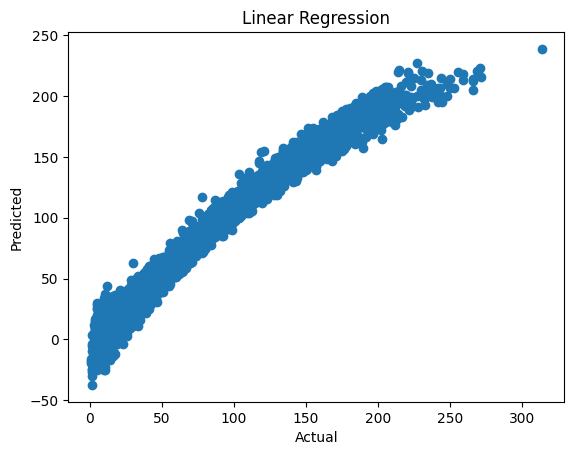

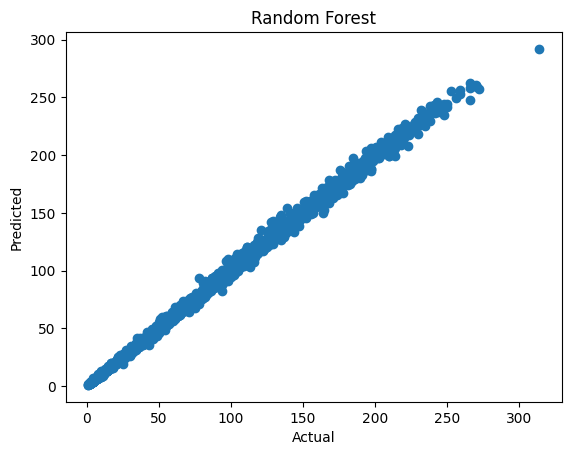

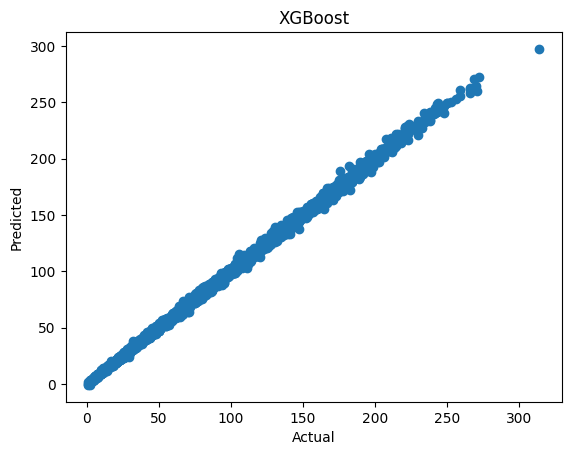

In [8]:
#Analysis of every model(Visualization)
import matplotlib.pyplot as plt
#Again, the same function of plot for every model
def plot(y_test, pred, title):
    plt.figure()
    plt.scatter(y_test, pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

plot(y_test, lr_pred, "Linear Regression")
plot(y_test, rf_pred, "Random Forest")
plot(y_test, xgb_pred, "XGBoost")

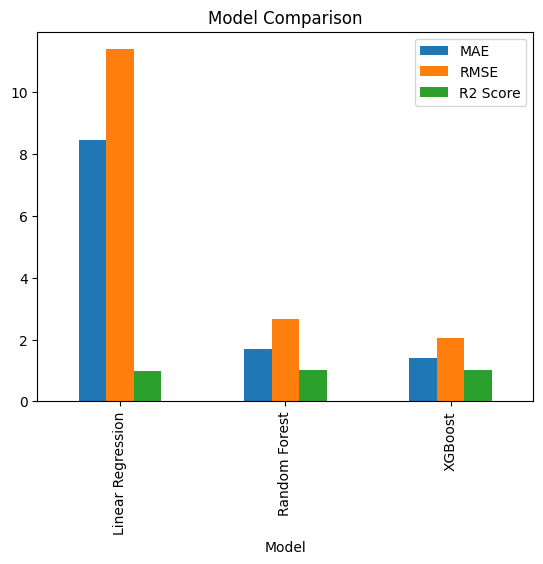

In [9]:
#Comparison between models
results.set_index("Model").plot(kind='bar')
plt.title("Model Comparison")
plt.show()